# Classification du taux de prévalence de la BPCO

Ce notebook entraîne plusieurs modèles de machine learning pour prédire le niveau de prévalence de la BPCO (Faible/Moyen/Élevé) à partir de données environnementales et économiques.

In [20]:
# Configuration
BASE_PATH = "/mnt/c/Users/ala78/OneDrive - HESSO/BA5/GML/data-gml-health/Refined"
folder_name = "9019"
file_name = "COPD_prevalence_rate_s_2"
file_format = "csv"

# Paramètres de validation
N_SPLITS = 10  # Nombre de répétitions du split 80/20
F1_THRESHOLD = 0.7  # Seuil F1-score pour l'analyse des features

In [21]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import re
import json
import random
import warnings
from pathlib import Path

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils import class_weight
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# SHAP
import shap

# Import du module de préparation des données
project_root = Path.cwd().parent
sys.path.append(str(project_root.resolve()))
import COPD.data_preparation as data_preparation

# Chargement des données
df = pd.read_csv(f"{BASE_PATH}/{folder_name}/{file_name}.{file_format}")
print(f"Données chargées : {df.shape}")

Données chargées : (5212, 44)


## Création de la variable cible

Division du taux de prévalence en 3 classes (tertiles) : Faible, Moyen, Élevé.

In [22]:
# Création de la variable cible en 3 classes (tertiles)
df['Y_class'] = pd.qcut(df['Value'], q=3, labels=[0, 1, 2], duplicates='drop')
df['Y_label'] = pd.qcut(df['Value'], q=3, labels=['Faible', 'Moyen', 'Élevé'], duplicates='drop')

print("Distribution de la cible :")
print(df['Y_label'].value_counts())

Distribution de la cible :
Y_label
Élevé     1738
Faible    1737
Moyen     1737
Name: count, dtype: int64


## Imputation des valeurs manquantes

In [23]:
# Sauvegarder les cibles avant imputation
y_class_saved = df['Y_class'].copy()
y_label_saved = df['Y_label'].copy()

# Colonnes à exclure de l'imputation (métadonnées et cibles)
cols_to_exclude = ['Measure', 'Country Name', 'Disease', 'Metric', 'Y_class', 'Y_label']
df_for_imputation = df.drop(columns=cols_to_exclude).copy()

# Preprocessing et imputation avec IterativeImputer
df_prepared = data_preparation.preprocessing(df_for_imputation)
df_imputed = data_preparation.impute_nans(df_prepared)

# Restaurer les cibles et calculer la vitesse du vent
df_imputed.index = df.index
df_imputed['Y_class'] = y_class_saved
df_imputed['Y_label'] = y_label_saved
df_imputed = data_preparation.process_wind_speed(df_imputed)

print(f"Données après imputation : {df_imputed.shape}")

📊 Colonnes détectées pour l'imputation : 38 colonnes

🔄 Étape 1/3 : Interpolation temporelle linéaire...
📈 Interpolation temporelle : 23985 valeurs imputées sur 38 colonnes.
   NaN restants après interpolation : 20299

🔄 Étape 2/3 : Forward/Backward fill résiduel...

🔄 Étape 3/3 : Imputation MICE (IterativeImputer)...
✅ 'Wind_Speed' calculée. Colonnes 'u10' et 'v10' non supprimées.
Données après imputation : (5212, 208)


## Feature Engineering

Normalisation des variables par population et suppression des colonnes redondantes.

In [24]:
# Colonnes à normaliser par habitant
cols_to_normalize_by_population = [
    'CO2 emissions', 'Total sales of agricultural pesticides (tonnes)',
    'Coal consumption', 'Energy use', 'Electricity use',
    'Raw materials extracted', 'Oil consumption', 'Sulfur emission', 'PM2.5 pollution'
]

# Colonnes à supprimer (ont déjà une version per capita ou sont redondantes)
cols_to_drop = ['GDP (current US$)', 'Surface area (sq. km)', 'Population, total', 'skt', 'd2m']

# Colonnes météo à arrondir
cols_meteo_to_round = ['t2m', 'sst']

# Calcul de la densité de population
if 'Population, total' in df_imputed.columns and 'Surface area (sq. km)' in df_imputed.columns:
    df_imputed['Population Density (per sq. km)'] = (
        df_imputed['Population, total'] / df_imputed['Surface area (sq. km)'].replace(0, np.nan)
    )

# Création des ratios per capita
for col in cols_to_normalize_by_population:
    if col in df_imputed.columns and 'Population, total' in df_imputed.columns:
        df_imputed[f"{col} (per capita)"] = df_imputed[col] / df_imputed['Population, total'].replace(0, np.nan)
        df_imputed = df_imputed.drop(columns=[col])

# Suppression des colonnes redondantes
for col in cols_to_drop:
    if col in df_imputed.columns:
        df_imputed = df_imputed.drop(columns=[col])

# Arrondissement des températures
for col in cols_meteo_to_round:
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].round(2)

print(f"Features après engineering : {df_imputed.shape[1] - 2} (hors cibles)")

Features après engineering : 202 (hors cibles)


## Préparation des features pour la modélisation

In [25]:
# Sélection des features (exclure cibles, Year et Country Code encodés)
cols_to_exclude = ['Value', 'Y_class', 'Y_label']
all_columns = df_imputed.drop(columns=cols_to_exclude).columns.tolist()
features_for_model = [col for col in all_columns 
                      if col != 'Year' and not col.startswith('Country Code_')]

# Création du DataFrame de modélisation
df_model = df_imputed[features_for_model + ['Y_class']].dropna(subset=['Y_class'])

print(f"Features pour modélisation : {len(features_for_model)}")
print(f"Échantillons : {len(df_model)}")

Features pour modélisation : 34
Échantillons : 5212


## Configuration des modèles

In [26]:
# Préparation de X et y
X = df_model.drop('Y_class', axis=1)
y = df_model['Y_class'].astype(int)

# Nettoyage des noms de colonnes pour compatibilité LightGBM
def clean_feature_name(name):
    cleaned = re.sub(r'[\[\]{}\"\'<>]', '', name)
    cleaned = re.sub(r'[,;:]', '_', cleaned)
    cleaned = re.sub(r'\s+', '_', cleaned)
    return cleaned.strip('_')

X.columns = [clean_feature_name(col) for col in X.columns]
feature_names = X.columns.tolist()

# Chargement de la configuration MLP optimisée depuis FineTuningMlp
from tensorflow.keras.layers import Input

MODEL_CONFIG_PATH = Path('models/model_config.json')
if MODEL_CONFIG_PATH.exists():
    with open(MODEL_CONFIG_PATH, 'r') as f:
        saved_config = json.load(f)
    MLP_CONFIG = {
        'hidden_layers': saved_config['hidden_layers'],
        'dropout_rate': saved_config['dropout_rate'],
        'learning_rate': saved_config['learning_rate'],
        'l2_reg': saved_config.get('l2_reg', 0.0),
        'use_batch_norm': saved_config.get('use_batch_norm', True),
        'batch_size': saved_config.get('batch_size', 64),
        'epochs': 150,
        'patience': 10
    }
    print(f"Configuration MLP chargée depuis {MODEL_CONFIG_PATH}")
else:
    MLP_CONFIG = {
        'hidden_layers': [128, 64, 32, 16],
        'dropout_rate': 0.2,
        'learning_rate': 0.001,
        'l2_reg': 0.001,
        'use_batch_norm': True,
        'batch_size': 64,
        'epochs': 150,
        'patience': 10
    }
    print("Configuration MLP par défaut utilisée")

def create_mlp_model(input_dim):
    """Crée un modèle MLP pour classification 3 classes."""
    model = Sequential()
    regularizer = l2(MLP_CONFIG['l2_reg']) if MLP_CONFIG['l2_reg'] > 0 else None
    
    # Couche d'entrée explicite (évite le warning)
    model.add(Input(shape=(input_dim,)))
    
    # Première couche cachée
    model.add(Dense(MLP_CONFIG['hidden_layers'][0], activation='relu', kernel_regularizer=regularizer))
    if MLP_CONFIG['use_batch_norm']:
        model.add(BatchNormalization())
    model.add(Dropout(MLP_CONFIG['dropout_rate']))
    
    # Couches suivantes
    for units in MLP_CONFIG['hidden_layers'][1:]:
        model.add(Dense(units, activation='relu', kernel_regularizer=regularizer))
        if MLP_CONFIG['use_batch_norm']:
            model.add(BatchNormalization())
        model.add(Dropout(MLP_CONFIG['dropout_rate']))
    
    # Sortie
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=MLP_CONFIG['learning_rate']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print(f"Features : {len(feature_names)}, Échantillons : {len(X)}")

Configuration MLP chargée depuis models/model_config.json
Features : 34, Échantillons : 5212


## Entraînement des modèles

Validation par répétitions multiples (N splits avec random states différents).

In [27]:
# Définition des modèles
initial_seed = random.randrange(2**31)
MODEL_NAMES = ['SVM (RBF)', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree', 'MLP (Keras)']
TREE_BASED_MODELS = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Decision Tree']
MODELS_FOR_SHAP = ['SVM (RBF)', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']

# Stockage des résultats
all_results = {name: {'accuracy': [], 'precision_weighted': [], 'recall_weighted': [], 'f1_weighted': []} 
               for name in MODEL_NAMES}
all_feature_importances = {name: [] for name in MODEL_NAMES}
all_confusion_matrices = {name: [] for name in MODEL_NAMES}
all_shap_values = {name: [] for name in MODELS_FOR_SHAP}
best_models = {}

# Fonction pour calculer l'importance par permutation
def get_permutation_importance(model, X, y, is_keras=False):
    y_pred_base = np.argmax(model.predict(X, verbose=0), axis=1) if is_keras else model.predict(X)
    baseline = accuracy_score(y, y_pred_base)
    importances = []
    for i in range(X.shape[1]):
        X_perm = X.copy() if isinstance(X, np.ndarray) else X.values.copy()
        np.random.shuffle(X_perm[:, i])
        y_pred = np.argmax(model.predict(X_perm, verbose=0), axis=1) if is_keras else model.predict(X_perm)
        importances.append(max(0, baseline - accuracy_score(y, y_pred)))
    return np.array(importances)

# Boucle d'entraînement
early_stop = EarlyStopping(monitor='val_loss', patience=MLP_CONFIG['patience'], restore_best_weights=True)

for split_idx in range(N_SPLITS):
    random_state = initial_seed + split_idx
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for model_name in MODEL_NAMES:
        # Création et entraînement du modèle
        if model_name == 'SVM (RBF)':
            model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=random_state)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            importances = get_permutation_importance(model, X_test_scaled, y_test.values)
        elif model_name == 'Random Forest':
            model = RandomForestClassifier(random_state=random_state, n_estimators=100)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.feature_importances_
        elif model_name == 'XGBoost':
            model = XGBClassifier(objective='multi:softmax', num_class=3, random_state=random_state, eval_metric='mlogloss')
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.feature_importances_
        elif model_name == 'LightGBM':
            model = LGBMClassifier(random_state=random_state, n_estimators=100, verbose=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.feature_importances_
        elif model_name == 'CatBoost':
            model = CatBoostClassifier(random_state=random_state, iterations=100, verbose=0, allow_writing_files=False)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.get_feature_importance()
        elif model_name == 'Decision Tree':
            model = DecisionTreeClassifier(random_state=random_state, max_depth=5, class_weight='balanced')
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importances = model.feature_importances_
        elif model_name == 'MLP (Keras)':
            tf.random.set_seed(random_state)
            model = create_mlp_model(X_train_scaled.shape[1])
            model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=MLP_CONFIG['epochs'],
                      batch_size=MLP_CONFIG['batch_size'], callbacks=[early_stop], verbose=0)
            y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)
            importances = get_permutation_importance(model, X_test_scaled, y_test.values, is_keras=True)
        
        # Calcul des métriques
        current_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        all_results[model_name]['accuracy'].append(accuracy_score(y_test, y_pred))
        all_results[model_name]['precision_weighted'].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        all_results[model_name]['recall_weighted'].append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        all_results[model_name]['f1_weighted'].append(current_f1)
        
        # Stockage des importances et matrices de confusion
        all_feature_importances[model_name].append({'importances': importances.copy(), 'f1_score': current_f1})
        all_confusion_matrices[model_name].append(confusion_matrix(y_test, y_pred, labels=[0, 1, 2]))
        
        # Stockage du meilleur modèle (dernier split)
        if split_idx == N_SPLITS - 1:
            best_models[model_name] = model
        
        # Calcul SHAP pour les modèles qualifiés
        if model_name in MODELS_FOR_SHAP and current_f1 >= F1_THRESHOLD:
            try:
                if model_name in TREE_BASED_MODELS:
                    explainer = shap.TreeExplainer(model)
                    X_shap = X_test.iloc[:50] if hasattr(X_test, 'iloc') else X_test[:50]
                    shap_vals = explainer.shap_values(X_shap)
                else:
                    background = shap.kmeans(X_train_scaled, 10)
                    explainer = shap.KernelExplainer(model.predict_proba, background)
                    shap_vals = explainer.shap_values(X_test_scaled[:50], nsamples=50)
                    X_shap = X_test_scaled[:50]
                
                all_shap_values[model_name].append({
                    'shap_values': shap_vals,
                    'X_data': X_shap.values if hasattr(X_shap, 'values') else X_shap,
                    'f1_score': current_f1
                })
            except Exception:
                pass

# Affichage des résultats
print(f"\nRésultats (moyenne sur {N_SPLITS} splits) :")
print(f"{'Modèle':<22} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 44)
for model_name in MODEL_NAMES:
    acc = np.mean(all_results[model_name]['accuracy'])
    f1 = np.mean(all_results[model_name]['f1_weighted'])
    print(f"{model_name:<22} {acc:>10.4f} {f1:>10.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]


Résultats (moyenne sur 10 splits) :
Modèle                   Accuracy   F1-Score
--------------------------------------------
SVM (RBF)                  0.7984     0.7975
Random Forest              0.9507     0.9507
XGBoost                    0.9477     0.9477
LightGBM                   0.9472     0.9472
CatBoost                   0.9253     0.9253
Decision Tree              0.5602     0.5489
MLP (Keras)                0.4983     0.4803


## Statistiques agrégées

In [28]:
# Tableau récapitulatif des performances
summary_data = []
for model_name in MODEL_NAMES:
    summary_data.append({
        'Modèle': model_name,
        'Accuracy': f"{np.mean(all_results[model_name]['accuracy']):.4f} ± {np.std(all_results[model_name]['accuracy']):.4f}",
        'F1-Score': f"{np.mean(all_results[model_name]['f1_weighted']):.4f} ± {np.std(all_results[model_name]['f1_weighted']):.4f}"
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

       Modèle        Accuracy        F1-Score
    SVM (RBF) 0.7984 ± 0.0147 0.7975 ± 0.0148
Random Forest 0.9507 ± 0.0052 0.9507 ± 0.0052
      XGBoost 0.9477 ± 0.0062 0.9477 ± 0.0062
     LightGBM 0.9472 ± 0.0058 0.9472 ± 0.0058
     CatBoost 0.9253 ± 0.0041 0.9253 ± 0.0042
Decision Tree 0.5602 ± 0.0199 0.5489 ± 0.0269
  MLP (Keras) 0.4983 ± 0.1278 0.4803 ± 0.1352


/tmp/ipykernel_137871/3304209183.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=MODEL_NAMES, patch_artist=True)
/tmp/ipykernel_137871/3304209183.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=MODEL_NAMES, patch_artist=True)
/tmp/ipykernel_137871/3304209183.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=MODEL_NAMES, patch_artist=True)
/tmp/ipykernel_137871/3304209183.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name 

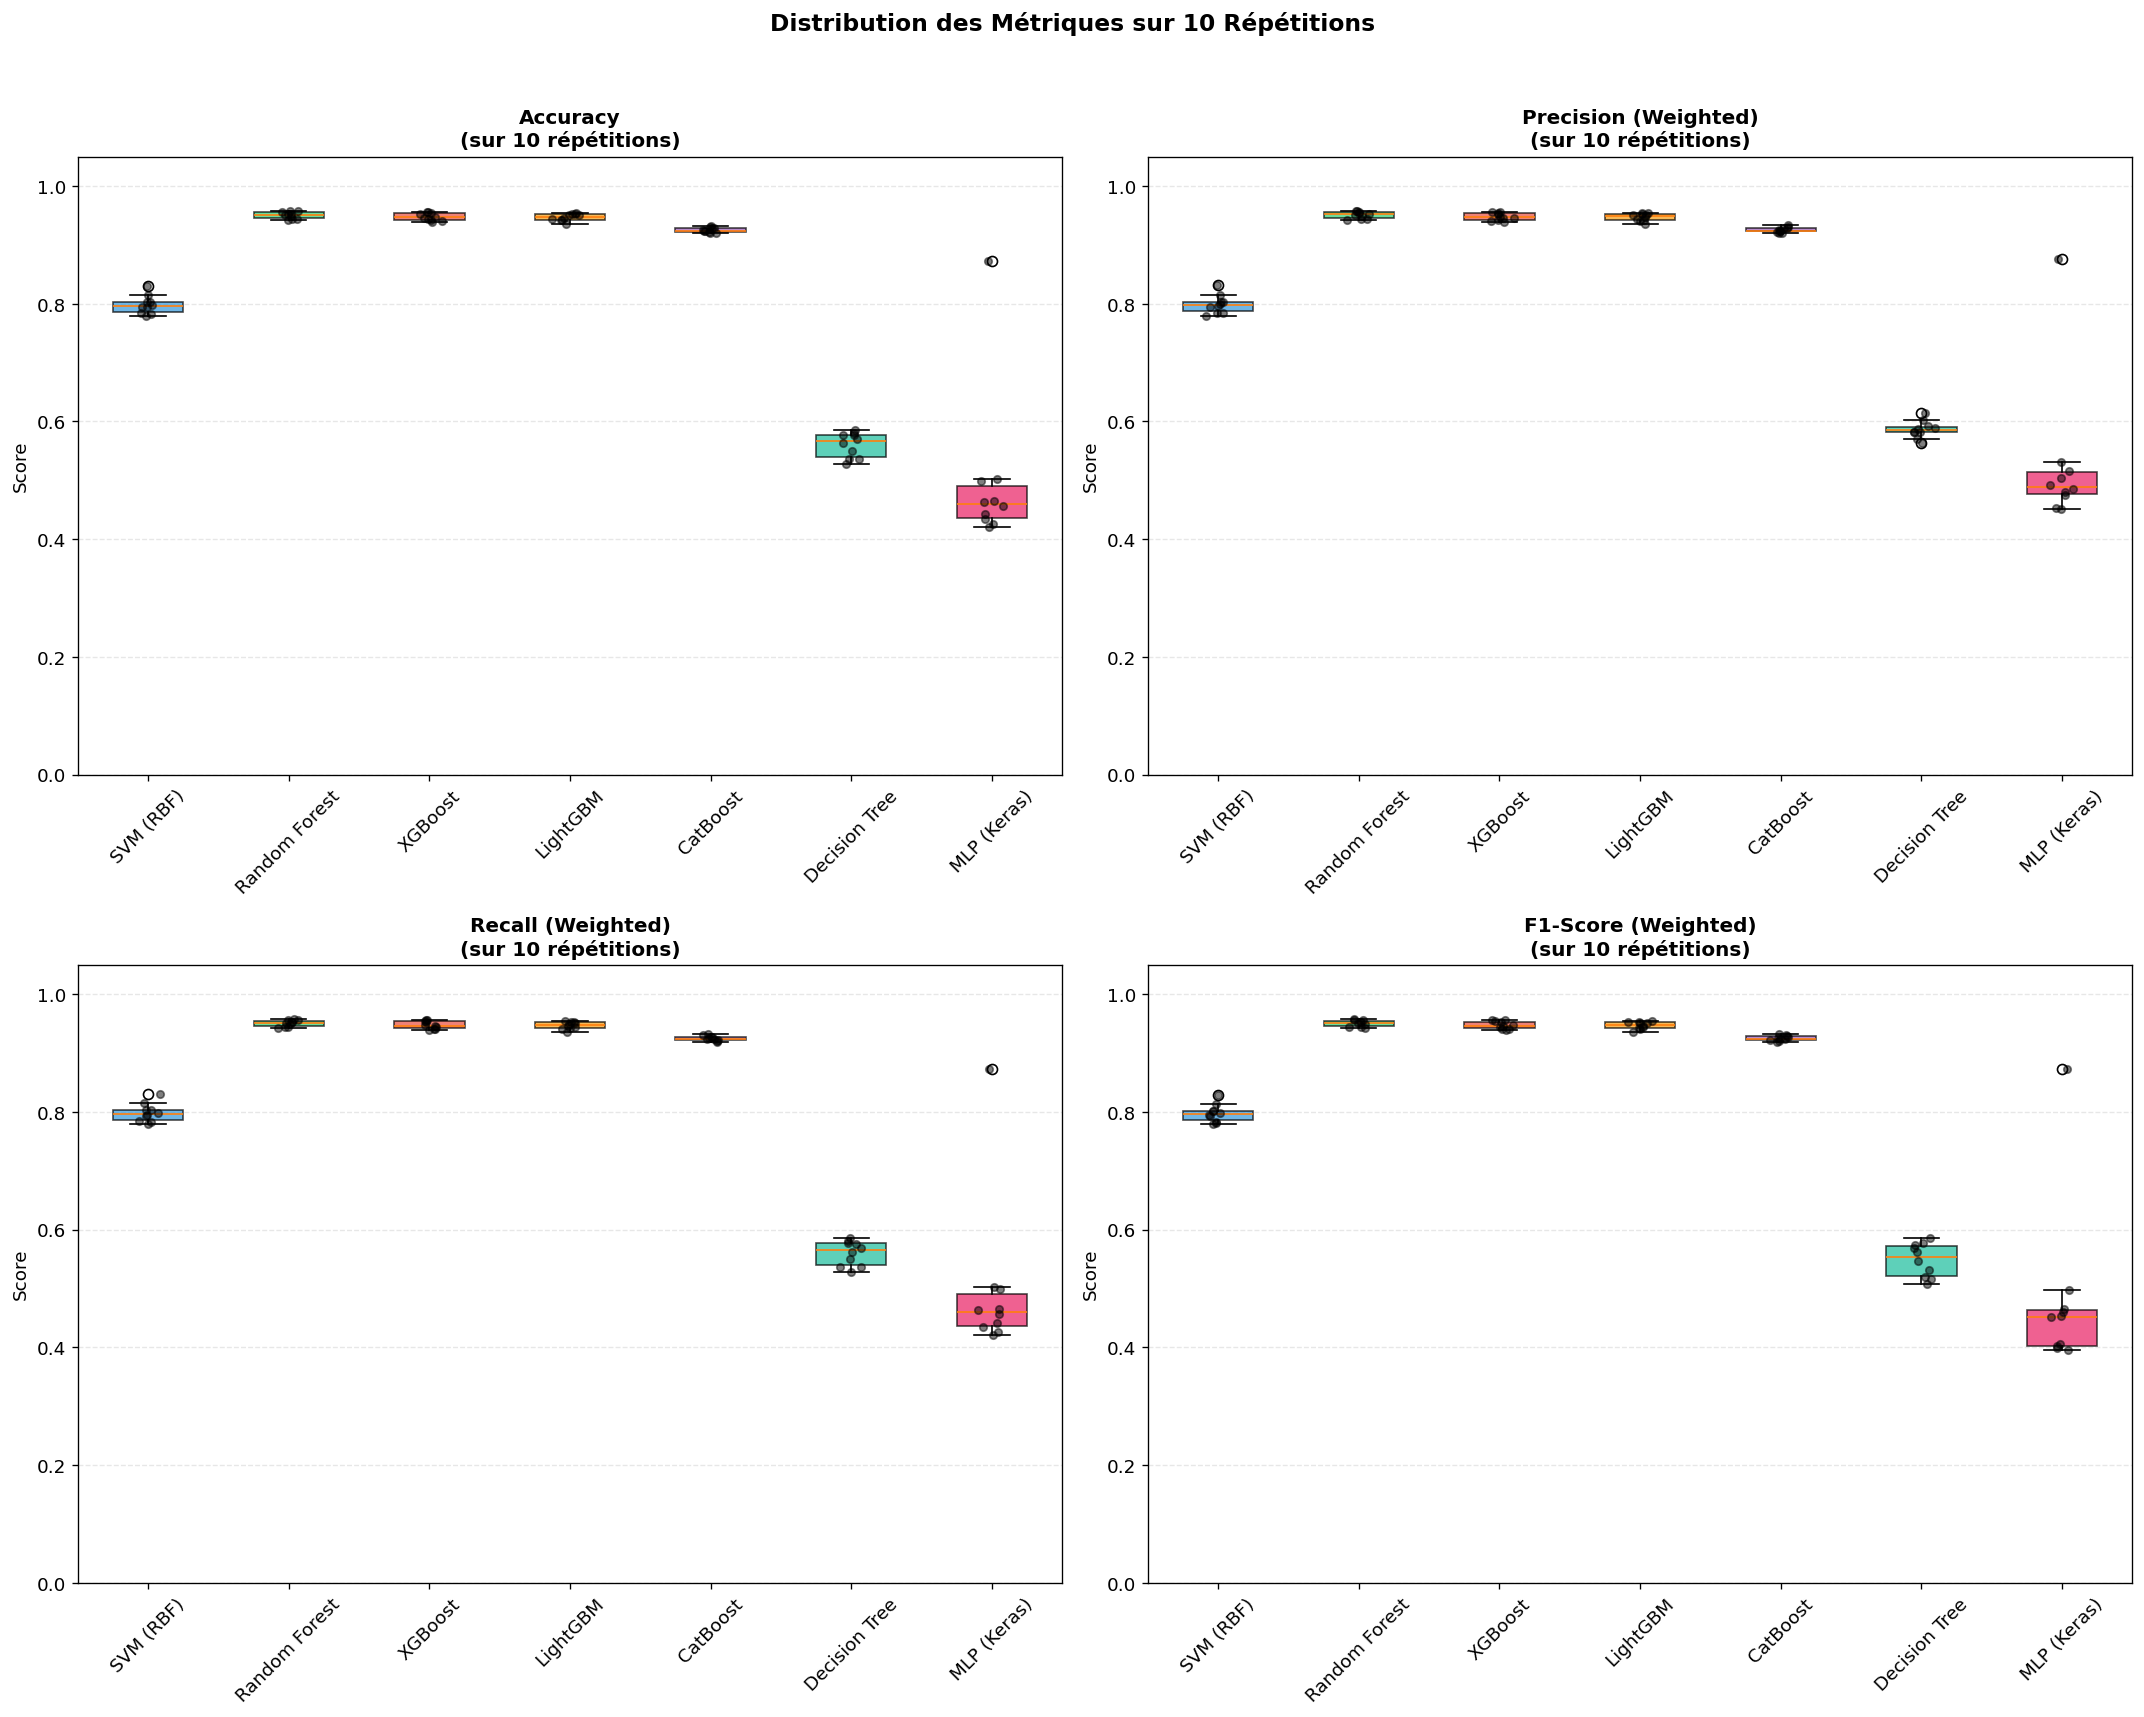

In [29]:
# Boxplots des distributions de métriques
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
titles = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e91e63']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    data = [all_results[m][metric] for m in MODEL_NAMES]
    bp = ax.boxplot(data, labels=MODEL_NAMES, patch_artist=True)
    
    for i, (patch, color) in enumerate(zip(bp['boxes'], colors)):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Ajouter les points individuels
    for i, values in enumerate(data):
        x = np.random.normal(i + 1, 0.04, size=len(values))
        ax.scatter(x, values, alpha=0.5, color='black', s=20, zorder=3)
    
    ax.set_title(f'{title}\n(sur {N_SPLITS} répétitions)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(f'Distribution des Métriques sur {N_SPLITS} Répétitions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("metrics_distribution_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

## Matrices de confusion

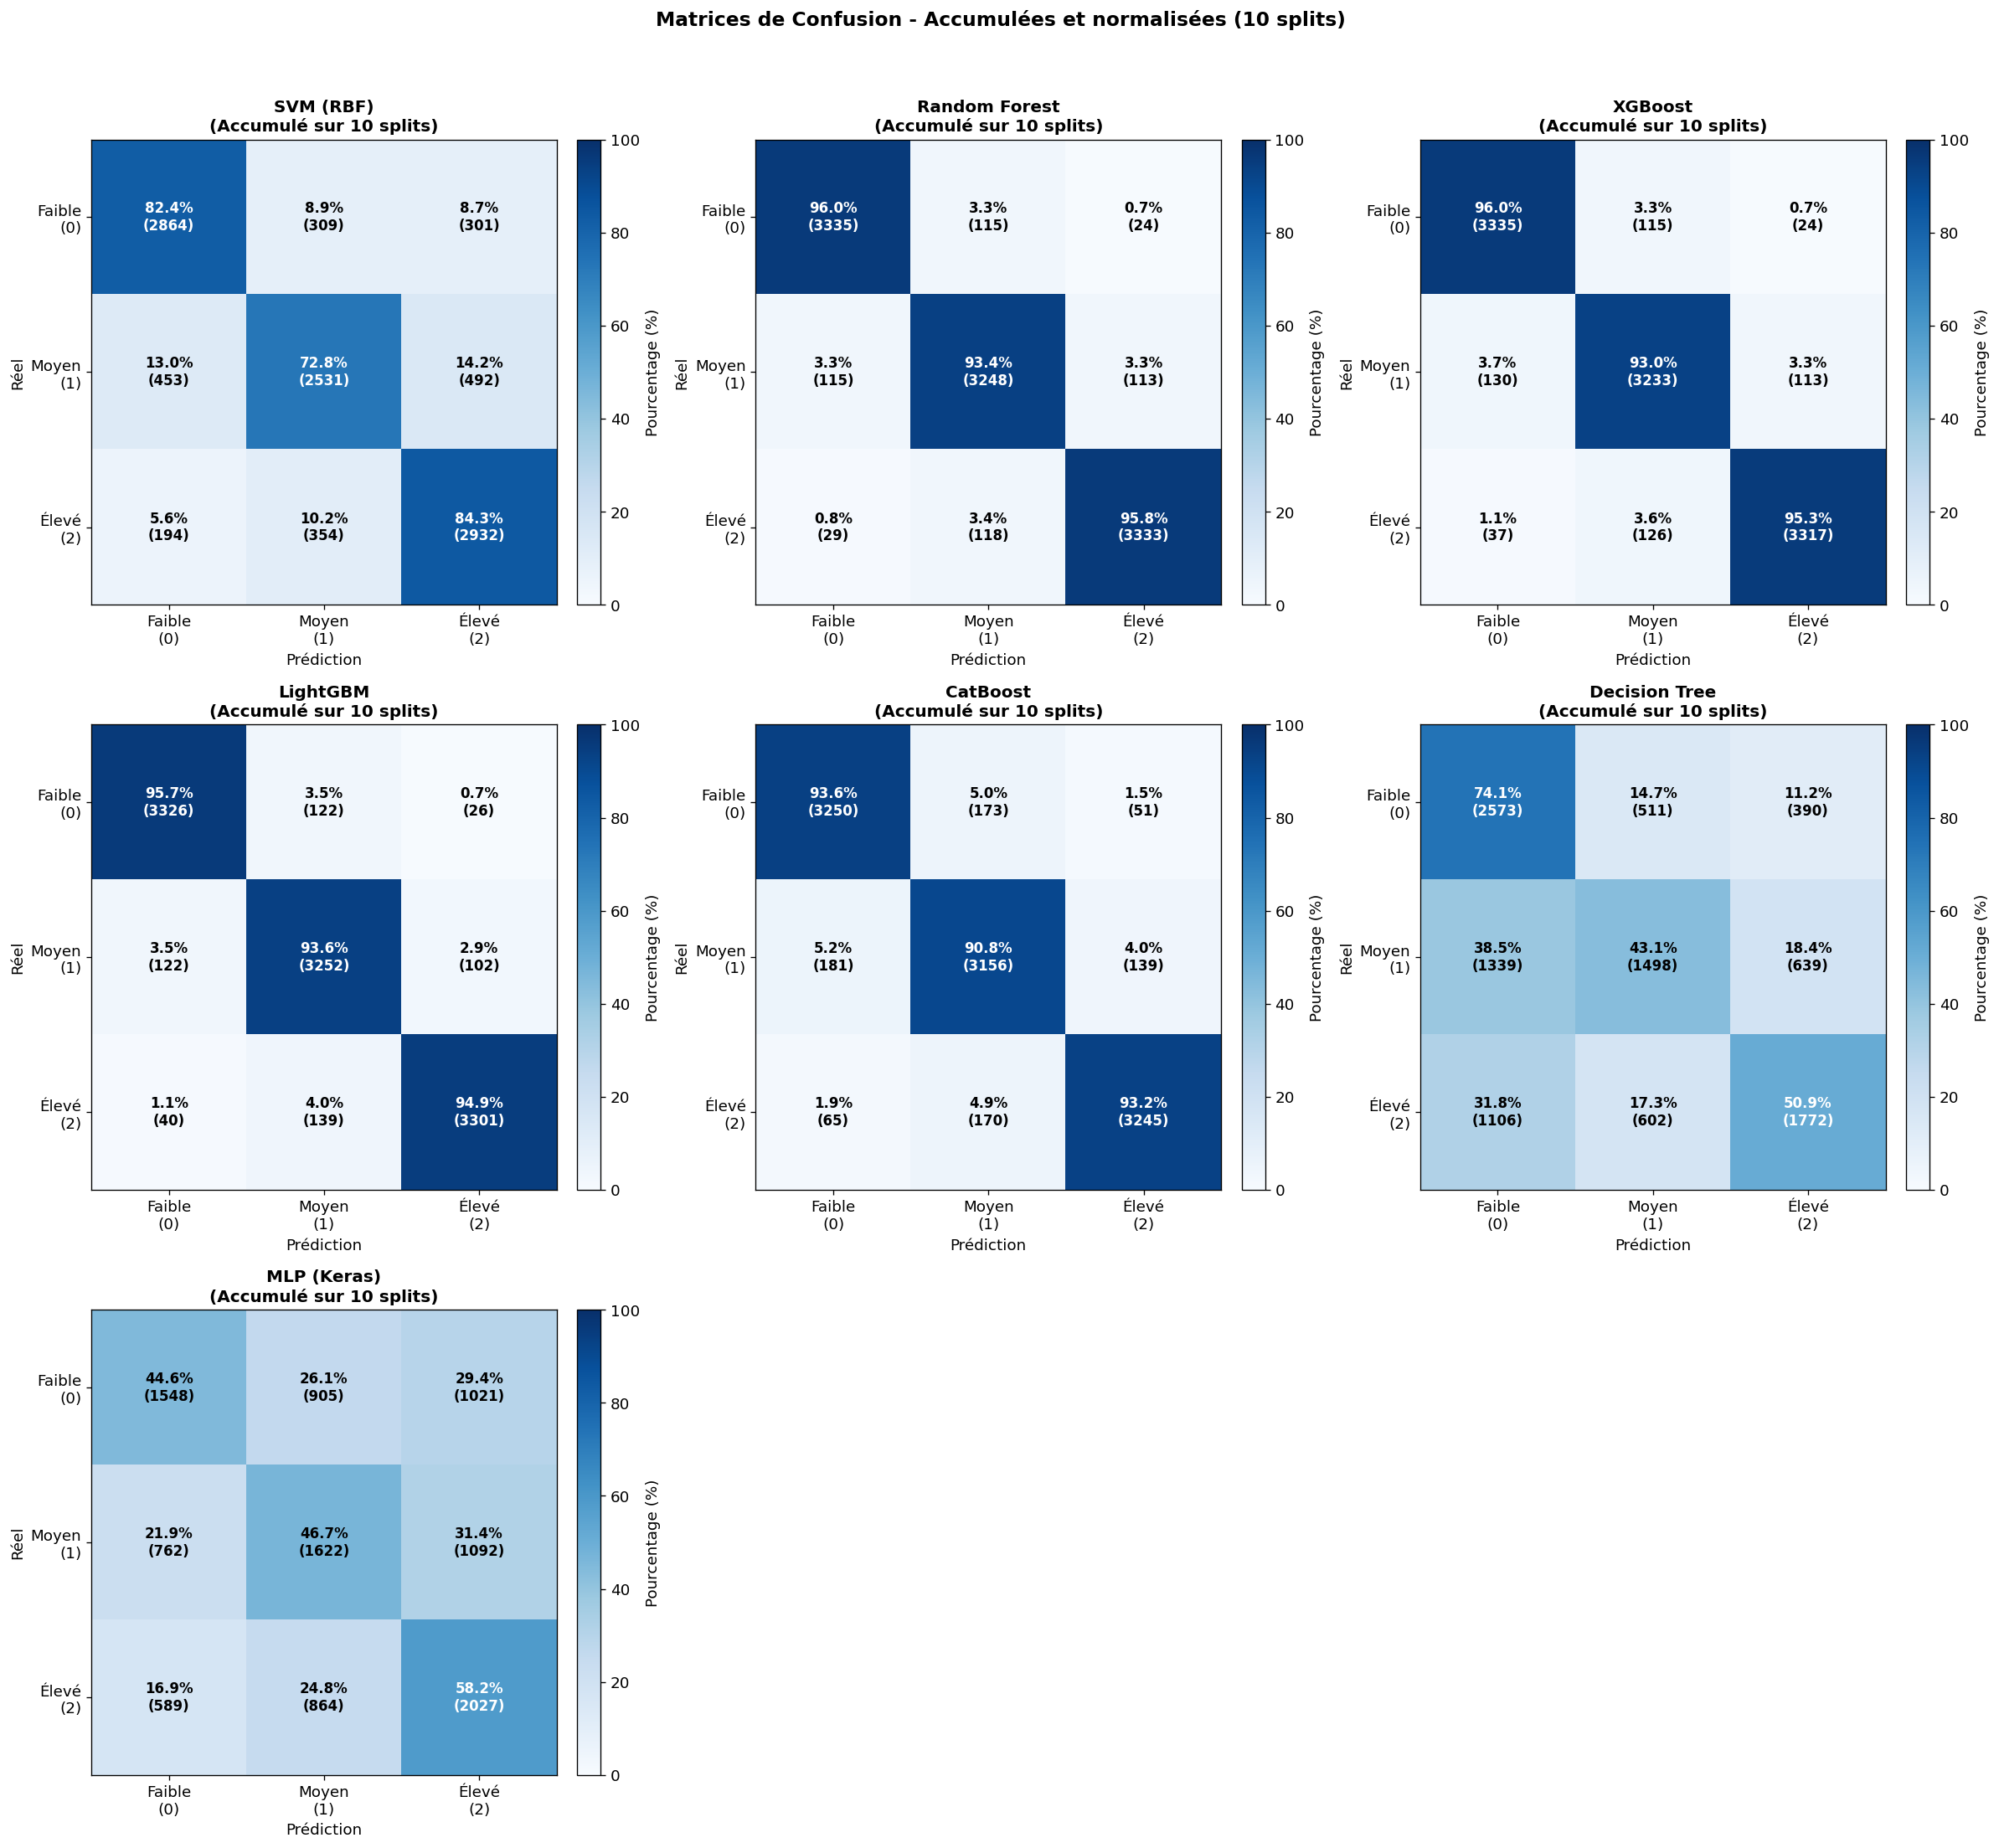

In [30]:
# Matrices de confusion accumulées et normalisées
n_models = len(MODEL_NAMES)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
display_labels = ['Faible\n(0)', 'Moyen\n(1)', 'Élevé\n(2)']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes = axes.flatten()

for idx, model_name in enumerate(MODEL_NAMES):
    accumulated_cm = sum(all_confusion_matrices[model_name])
    row_sums = accumulated_cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    normalized_cm = (accumulated_cm / row_sums) * 100
    
    # Annotation avec % et compte brut
    annot = np.empty_like(normalized_cm, dtype=object)
    for i in range(3):
        for j in range(3):
            annot[i, j] = f'{normalized_cm[i, j]:.1f}%\n({int(accumulated_cm[i, j])})'
    
    im = axes[idx].imshow(normalized_cm, cmap='Blues', vmin=0, vmax=100)
    
    for i in range(3):
        for j in range(3):
            color = 'white' if normalized_cm[i, j] > 50 else 'black'
            axes[idx].text(j, i, annot[i, j], ha='center', va='center', 
                          color=color, fontweight='bold', fontsize=10)
    
    axes[idx].set_xticks(range(3))
    axes[idx].set_yticks(range(3))
    axes[idx].set_xticklabels(display_labels)
    axes[idx].set_yticklabels(display_labels)
    axes[idx].set_xlabel('Prédiction')
    axes[idx].set_ylabel('Réel')
    axes[idx].set_title(f'{model_name}\n(Accumulé sur {N_SPLITS} splits)', fontsize=12, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    cbar.set_label('Pourcentage (%)')

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Matrices de Confusion - Accumulées et normalisées ({N_SPLITS} splits)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

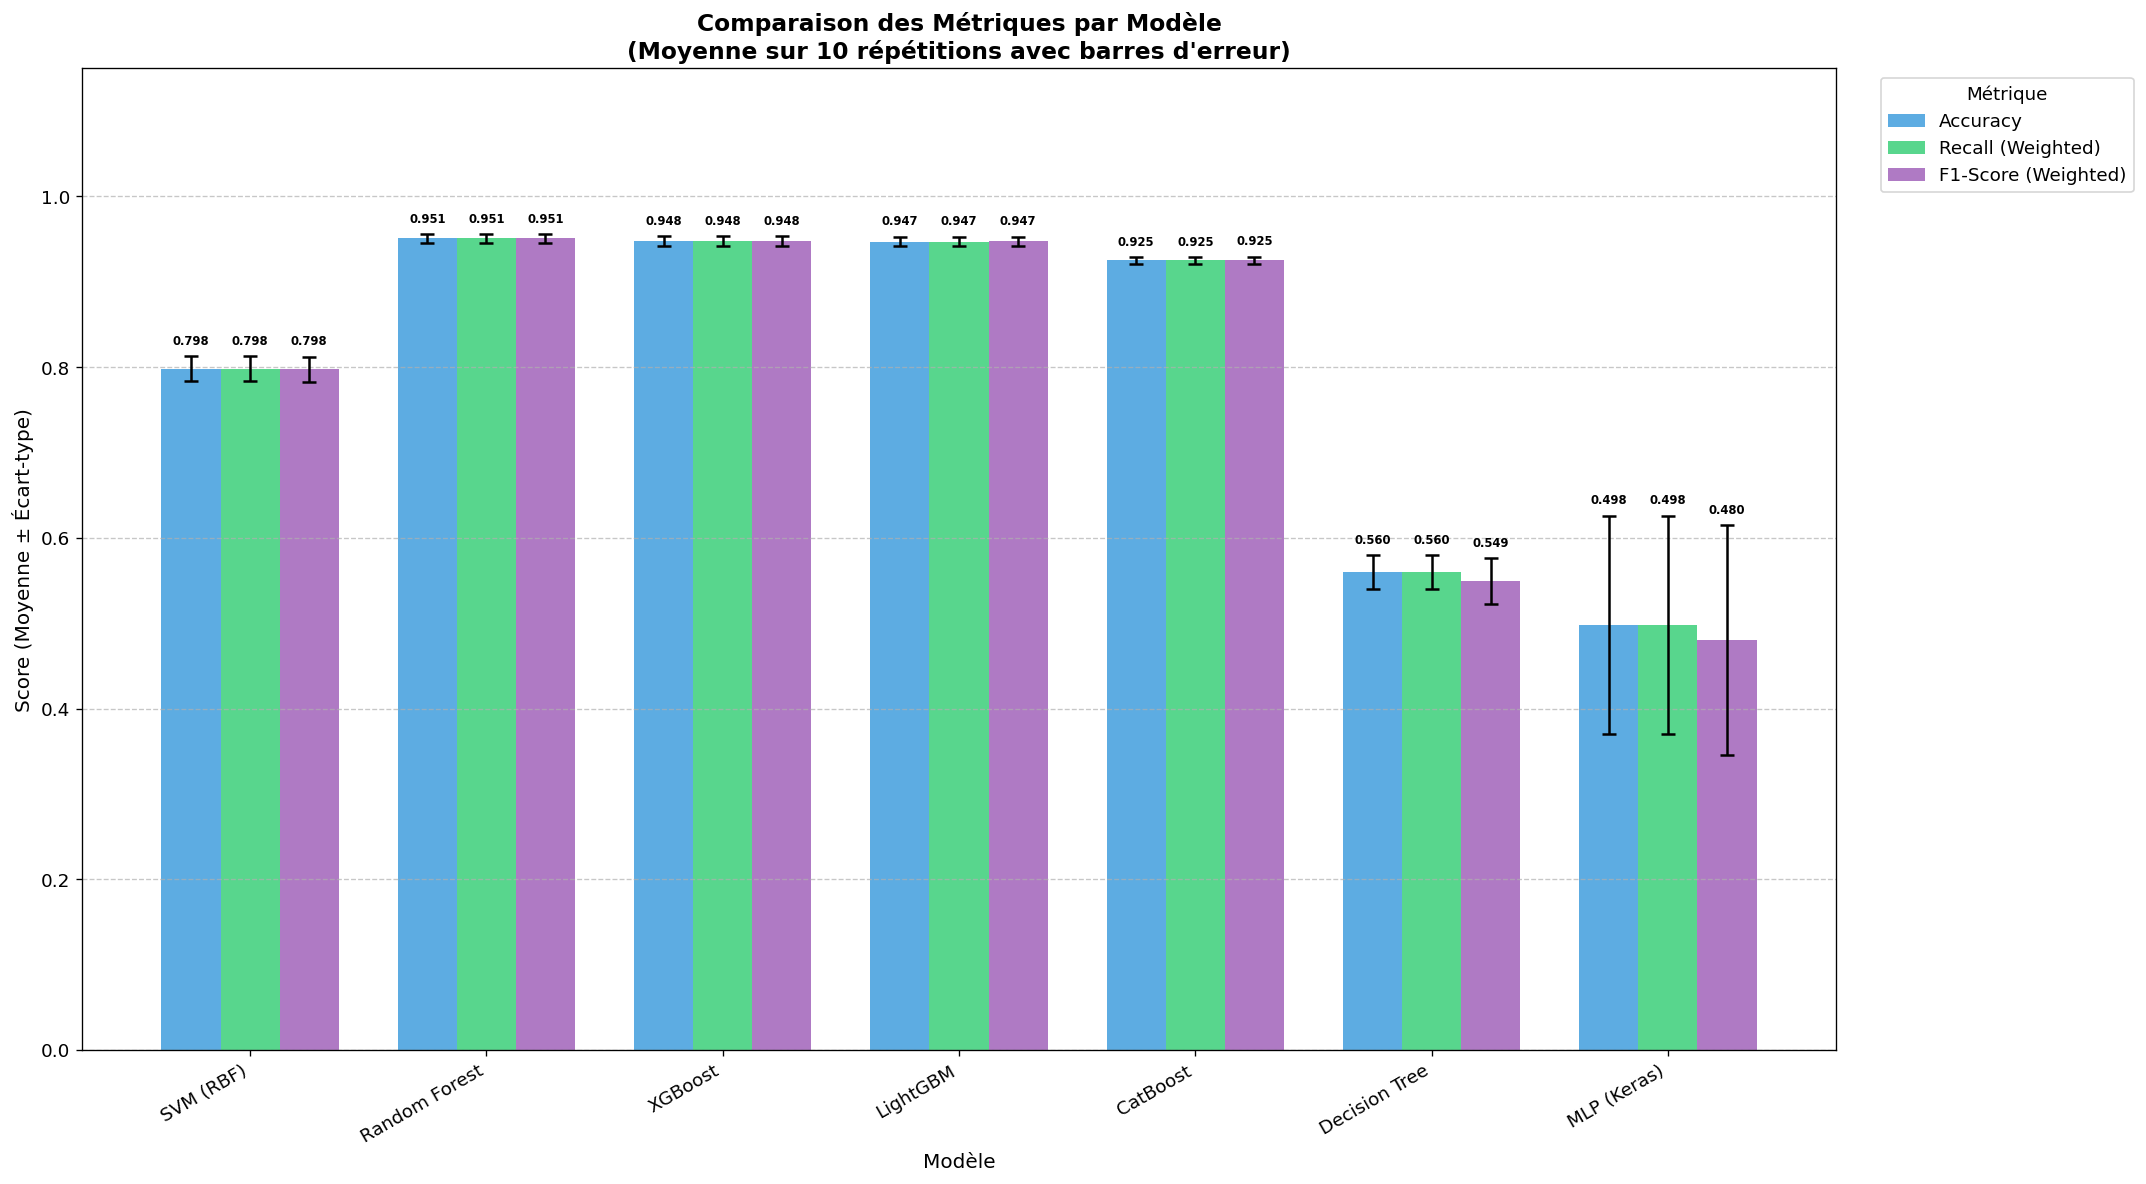

In [31]:
# Comparaison des métriques avec barres d'erreur
metrics_to_compare = ['Accuracy', 'Recall (Weighted)', 'F1-Score (Weighted)']
metric_keys = ['accuracy', 'recall_weighted', 'f1_weighted']
colors = ['#3498db', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(18, 10))
x = np.arange(len(MODEL_NAMES))
width = 0.25

for i, (metric_name, metric_key, color) in enumerate(zip(metrics_to_compare, metric_keys, colors)):
    means = [np.mean(all_results[m][metric_key]) for m in MODEL_NAMES]
    stds = [np.std(all_results[m][metric_key]) for m in MODEL_NAMES]
    bars = ax.bar(x + i*width, means, width, label=metric_name, color=color, alpha=0.8)
    ax.errorbar(x + i*width, means, yerr=stds, fmt='none', color='black', capsize=4, capthick=1.5)
    
    # Valeurs sur les barres
    for bar, mean, std in zip(bars, means, stds):
        ax.annotate(f'{mean:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01),
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_ylabel('Score (Moyenne ± Écart-type)', fontsize=12)
ax.set_xlabel('Modèle', fontsize=12)
ax.set_title(f'Comparaison des Métriques par Modèle\n(Moyenne sur {N_SPLITS} répétitions avec barres d\'erreur)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(MODEL_NAMES, rotation=30, ha='right')
ax.legend(title='Métrique', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("model_metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Importance des features

In [32]:
# Analyse des importances avec filtrage par F1-score
all_importance_records = []

for model_name, importance_list in all_feature_importances.items():
    for split_idx, data in enumerate(importance_list):
        if data['f1_score'] < F1_THRESHOLD:
            continue
        
        importances = data['importances']
        total = importances.sum()
        importances_pct = (importances / total) * 100 if total > 0 else importances
        
        for feat_idx, (feat_name, imp_pct) in enumerate(zip(feature_names, importances_pct)):
            all_importance_records.append({
                'Modèle': model_name,
                'Feature': feat_name,
                'Importance (%)': imp_pct
            })

df_all_importances = pd.DataFrame(all_importance_records)

# Top 15 features par importance moyenne
pivot_importance = df_all_importances.groupby(['Modèle', 'Feature'])['Importance (%)'].mean().unstack(level=0)
pivot_importance['Moyenne'] = pivot_importance.mean(axis=1)
top15_global = pivot_importance.sort_values('Moyenne', ascending=False).head(15)

print(f"Top 15 Features (importance moyenne, F1 ≥ {F1_THRESHOLD}) :\n")
print(top15_global.round(2).to_string())

Top 15 Features (importance moyenne, F1 ≥ 0.7) :

Modèle                                                                      CatBoost  LightGBM  MLP (Keras)  Random Forest  SVM (RBF)  XGBoost  Moyenne
Feature                                                                                                                                                
Prevalence_tobacco_use                                                          6.17      4.40         3.91           4.25       6.75     4.06     4.92
Industry_workers_(%)                                                            2.92      3.48         6.63           2.85       6.46     2.20     4.09
People_using_at_least_basic_sanitation_services_(%_of_population)               4.39      3.64         5.02           4.23       2.76     4.36     4.07
Population_Density_(per_sq._km)                                                 6.62      5.56         1.44           4.08       1.74     3.45     3.81
Agriculture_workers_(%)               

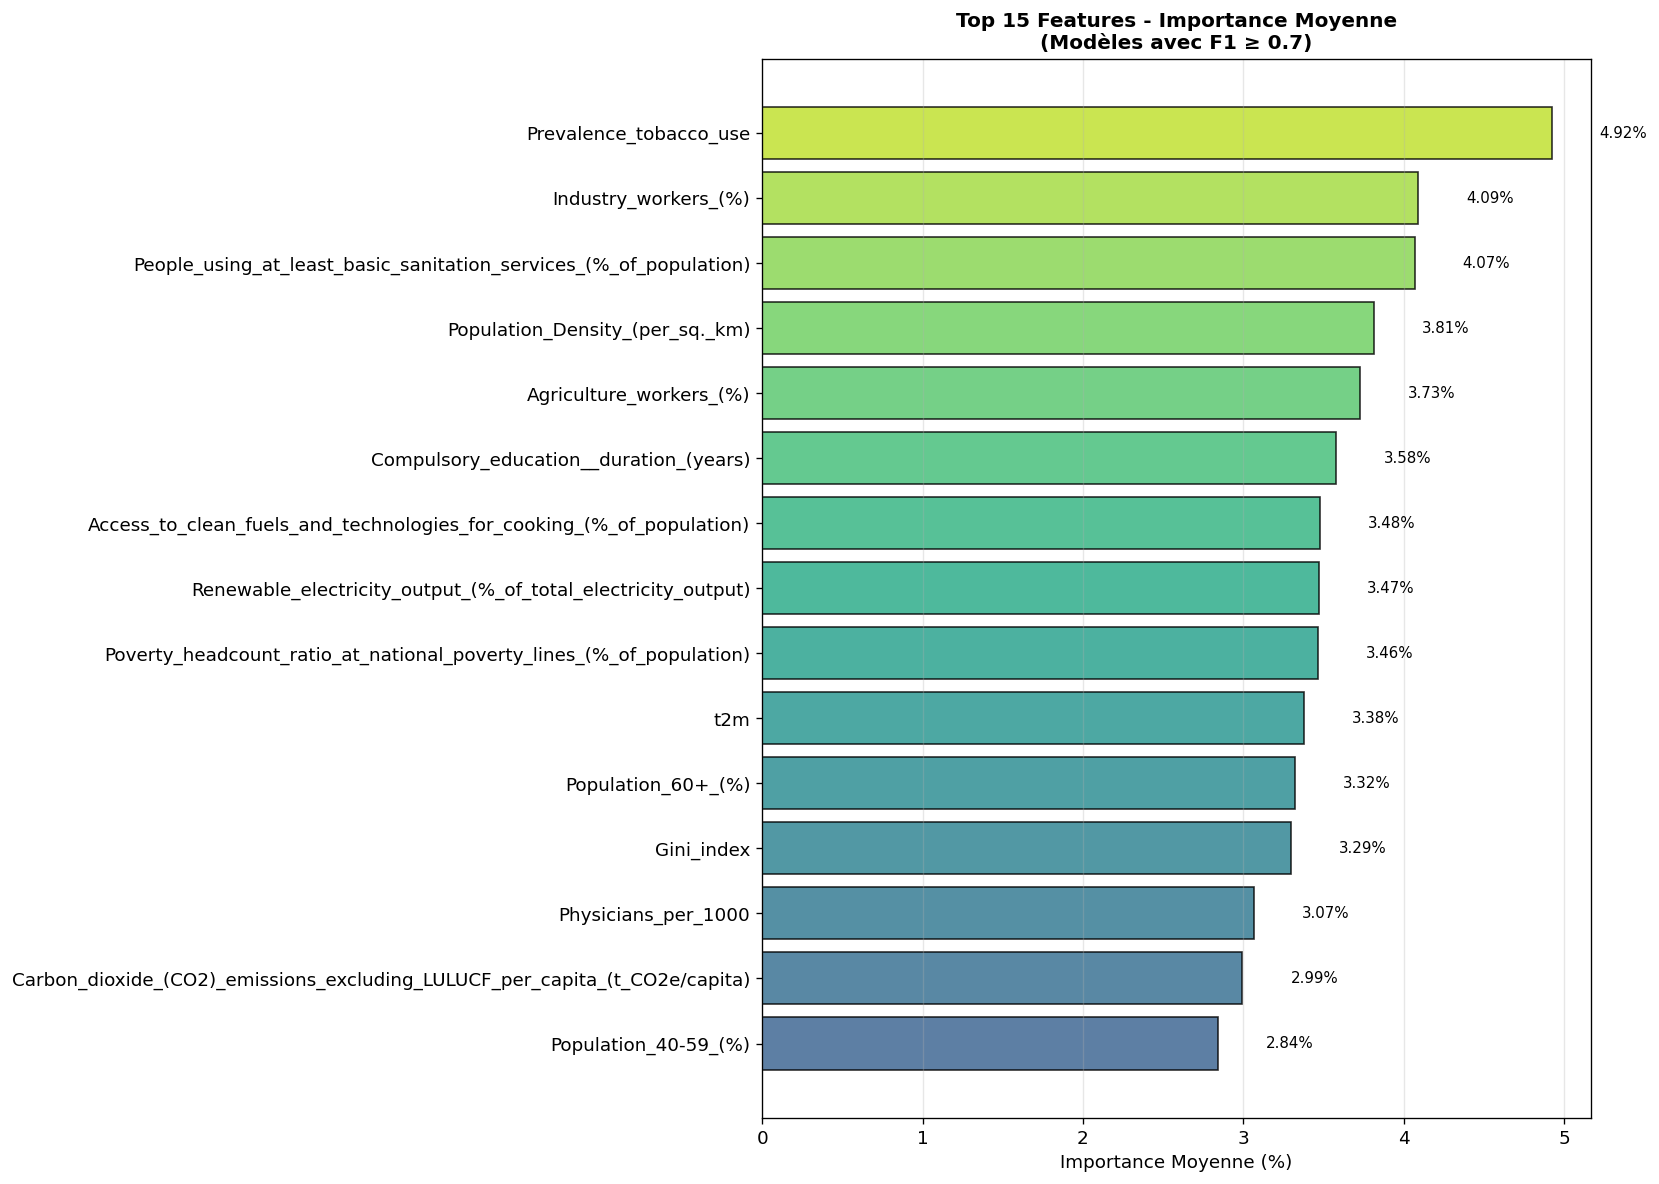

In [33]:
# Visualisation de l'importance des features
fig, ax = plt.subplots(figsize=(14, 10))

top15 = top15_global.drop(columns=['Moyenne']).head(15)
top15_means = top15.mean(axis=1).sort_values(ascending=True)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top15_means)))
bars = ax.barh(top15_means.index, top15_means.values, color=colors, alpha=0.8, edgecolor='black')

ax.set_xlabel('Importance Moyenne (%)', fontsize=11)
ax.set_title(f'Top 15 Features - Importance Moyenne\n(Modèles avec F1 ≥ {F1_THRESHOLD})', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Valeurs sur les barres
for bar, val in zip(bars, top15_means.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## Analyse SHAP

Interprétabilité des modèles avec les valeurs SHAP agrégées.

In [34]:
# Agrégation des valeurs SHAP sur toutes les itérations
output_dir = "outputs_shap"
os.makedirs(output_dir, exist_ok=True)

aggregated_shap = {}

for model_name in MODELS_FOR_SHAP:
    shap_data_list = all_shap_values[model_name]
    if not shap_data_list:
        continue
    
    # Concaténation des valeurs SHAP et X_data
    all_shap_class = []
    all_X_data = []
    
    for item in shap_data_list:
        shap_vals = item['shap_values']
        X_data = item['X_data']
        
        # Prendre la classe 2 (Élevé) pour l'analyse
        if isinstance(shap_vals, list):
            shap_class = shap_vals[2] if len(shap_vals) > 2 else shap_vals[-1]
        elif isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
            shap_class = shap_vals[:, :, 2]
        else:
            shap_class = shap_vals
        
        all_shap_class.append(shap_class)
        all_X_data.append(X_data)
    
    concat_shap = np.vstack(all_shap_class)
    concat_X = np.vstack(all_X_data)
    
    aggregated_shap[model_name] = {
        'shap_values': concat_shap,
        'X_data': concat_X,
        'n_iterations': len(shap_data_list),
        'total_samples': concat_shap.shape[0]
    }

print(f"Valeurs SHAP agrégées pour {len(aggregated_shap)} modèles")

Valeurs SHAP agrégées pour 5 modèles


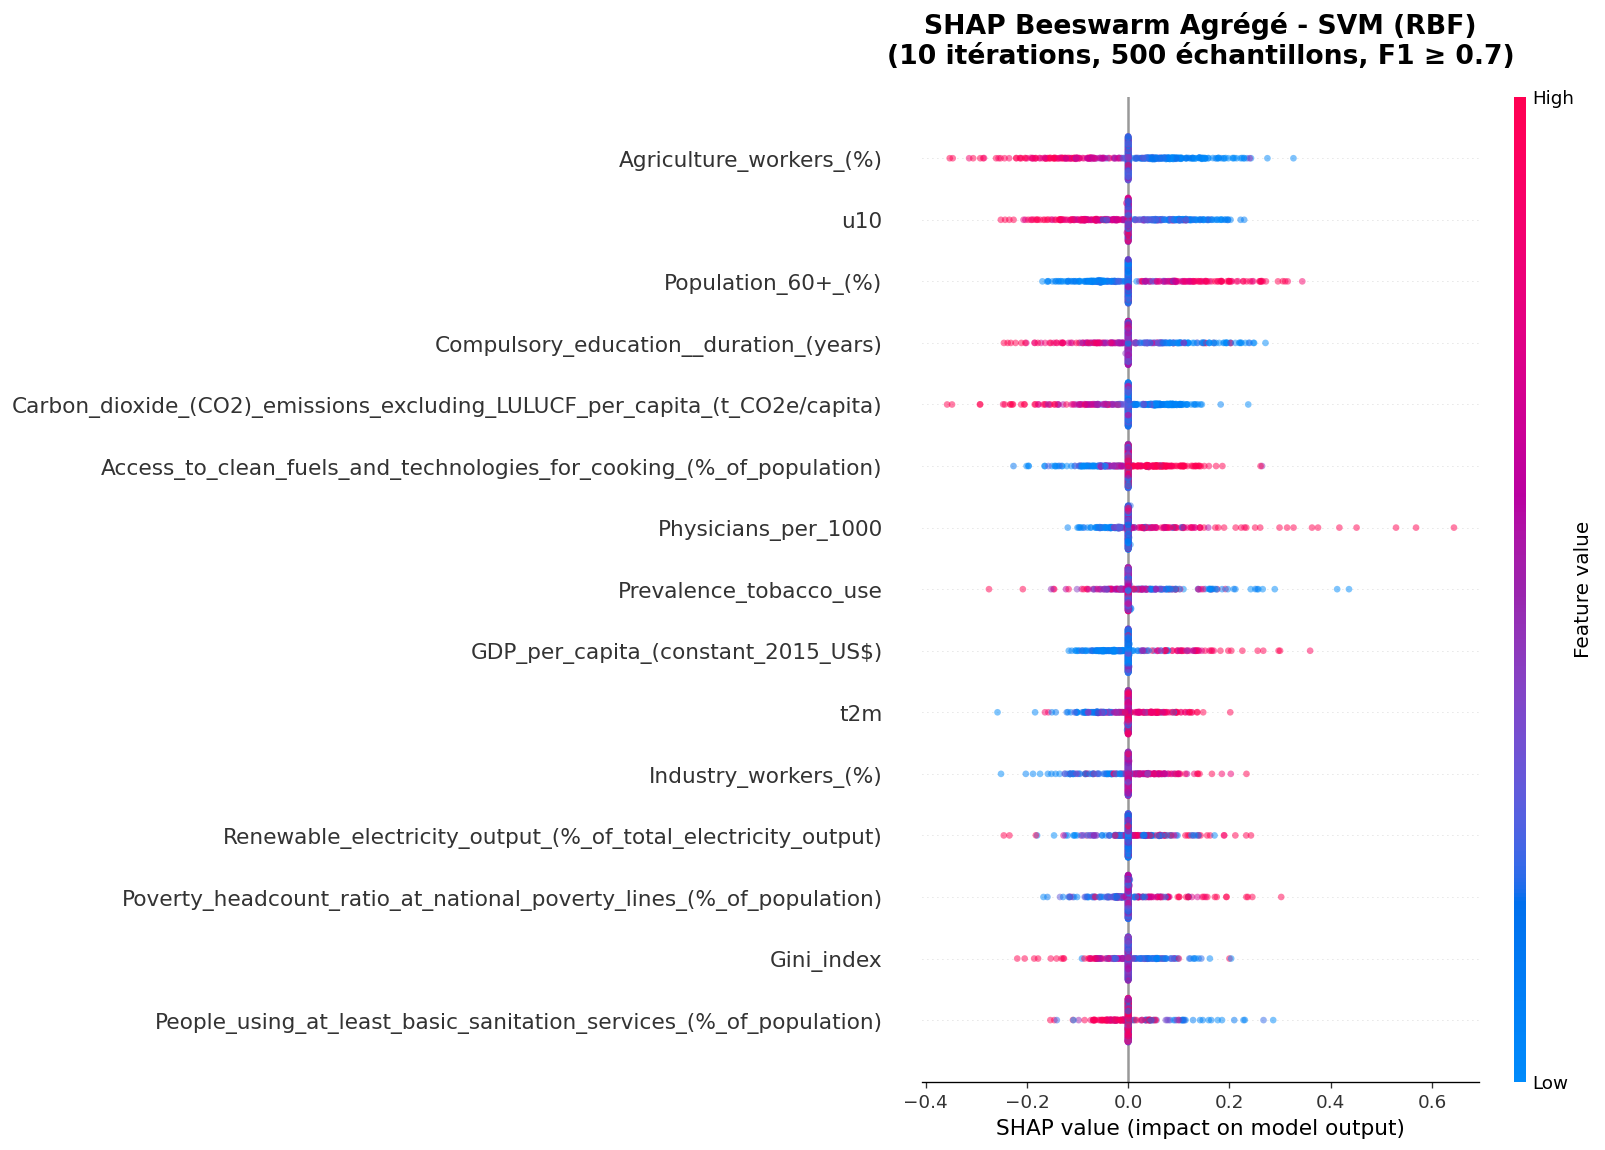

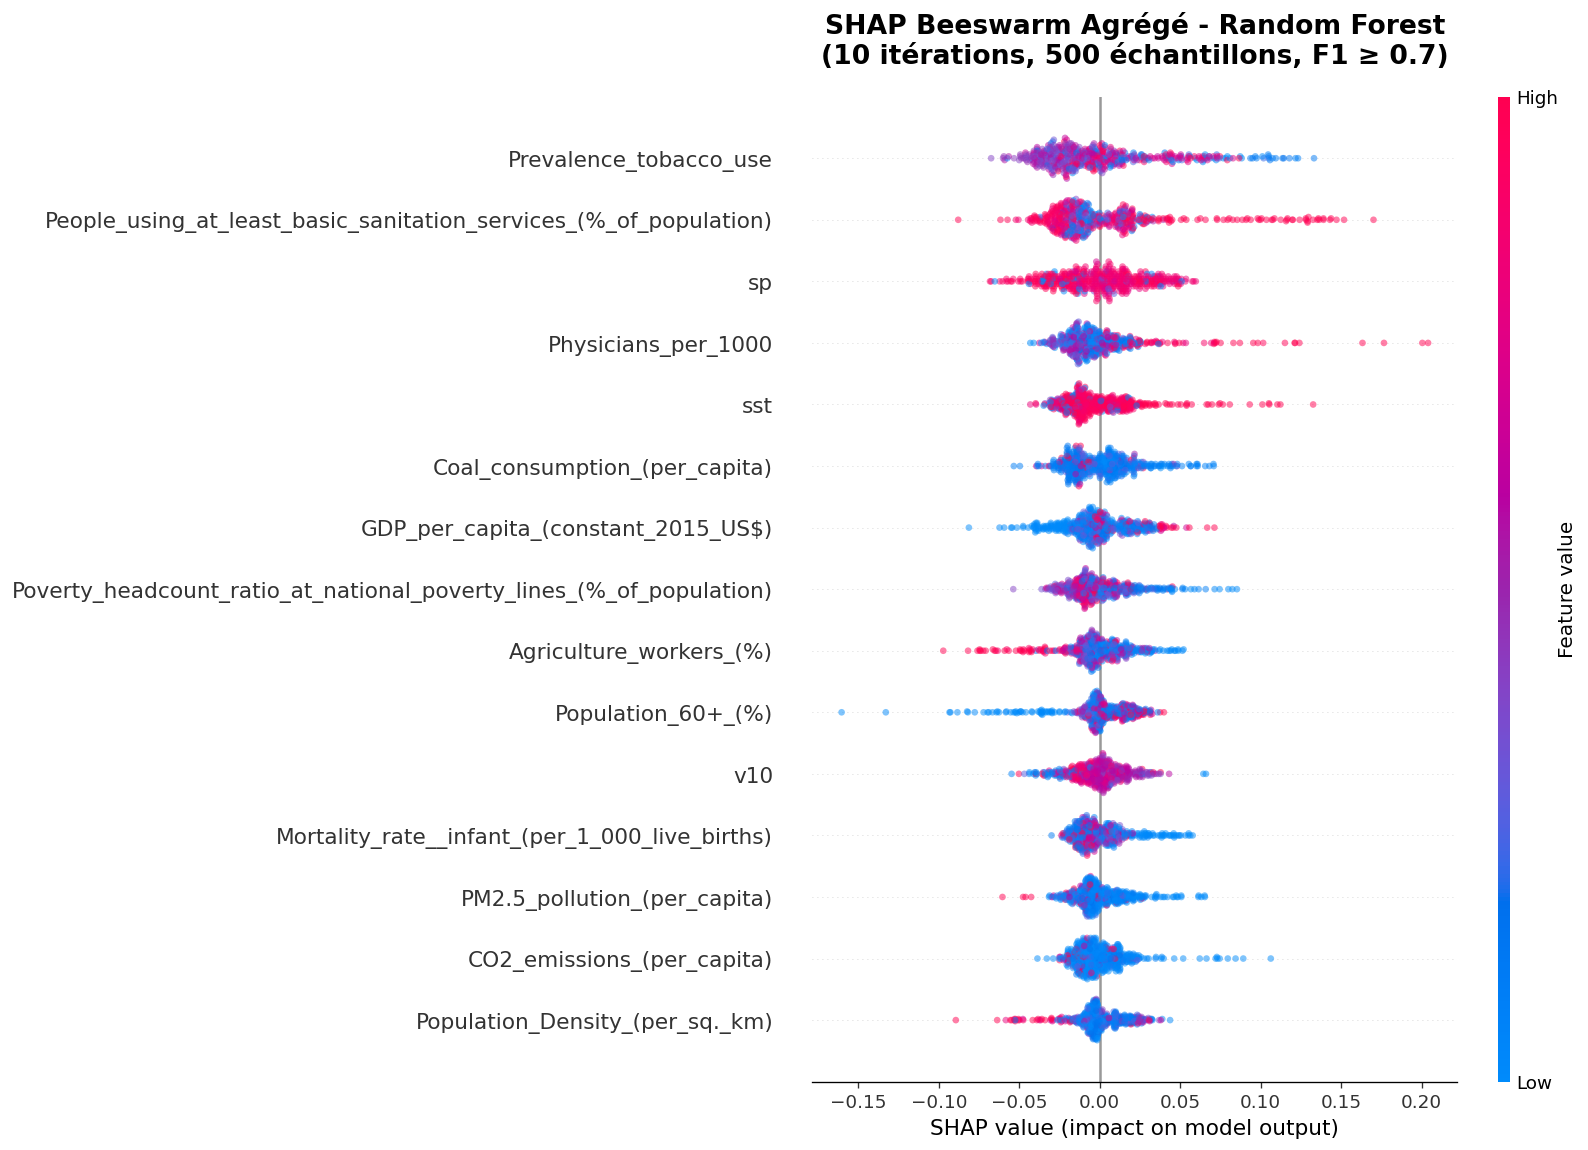

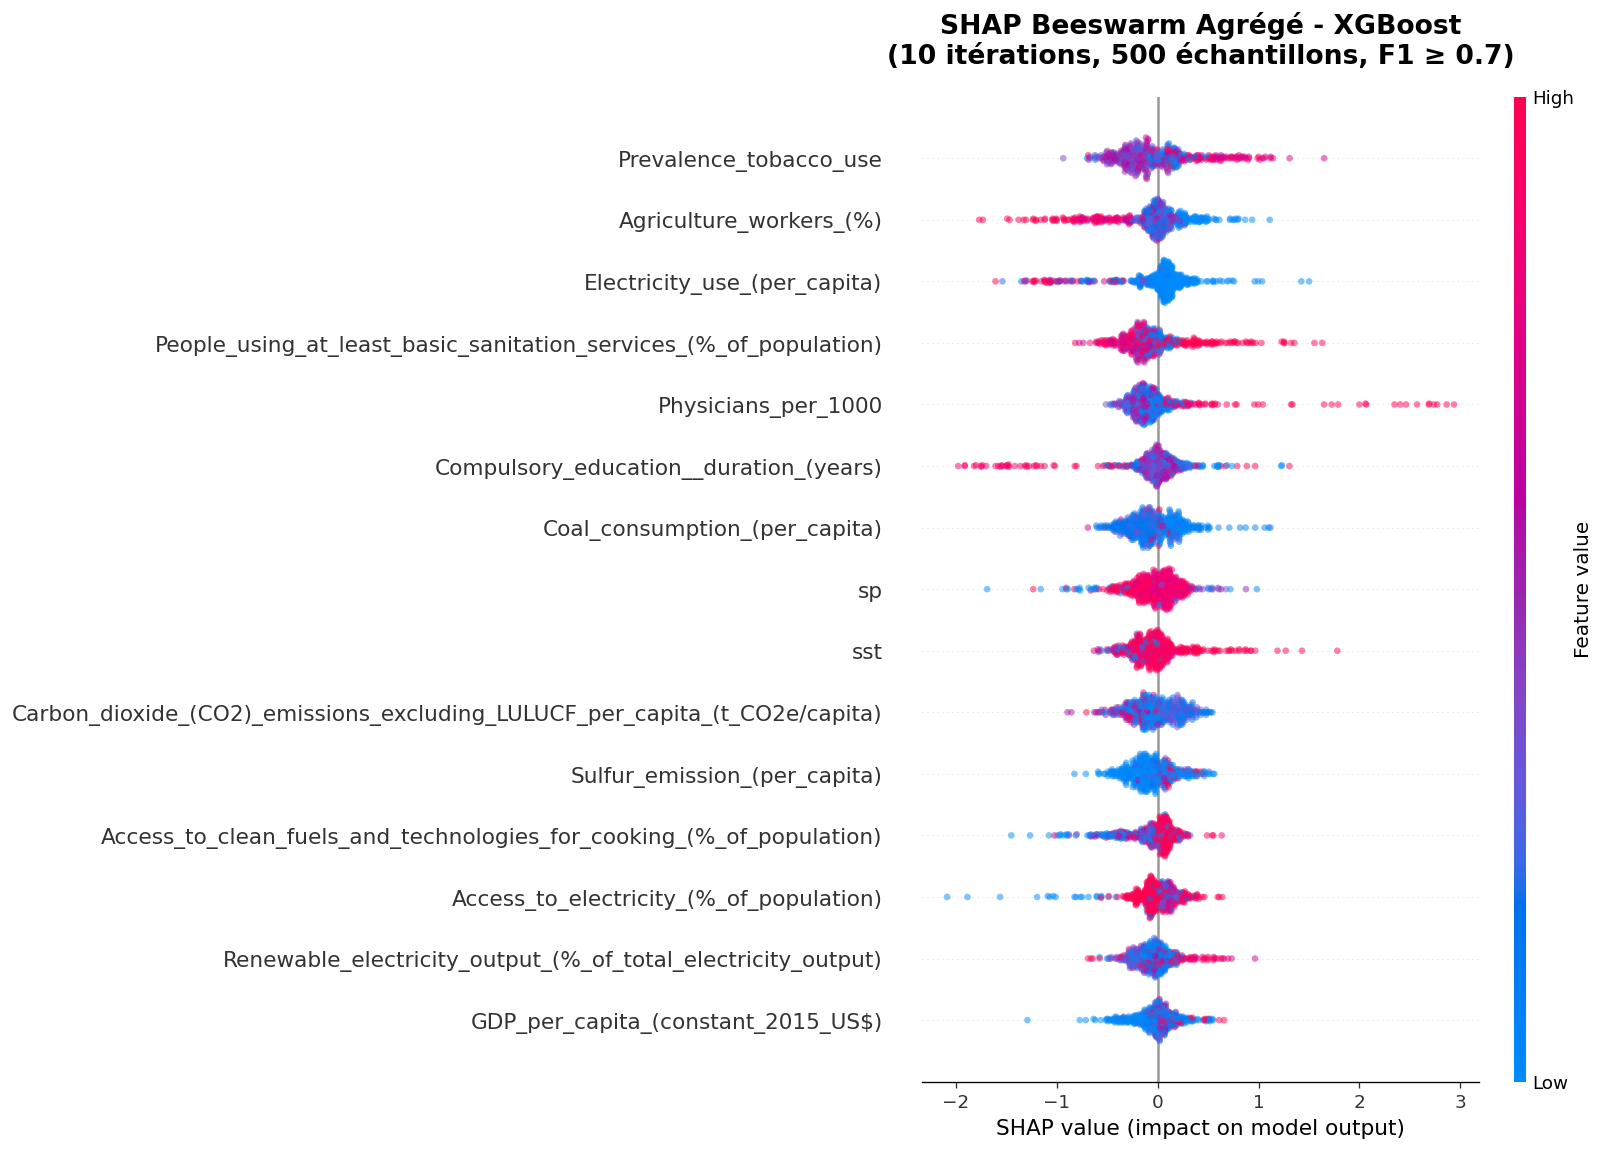

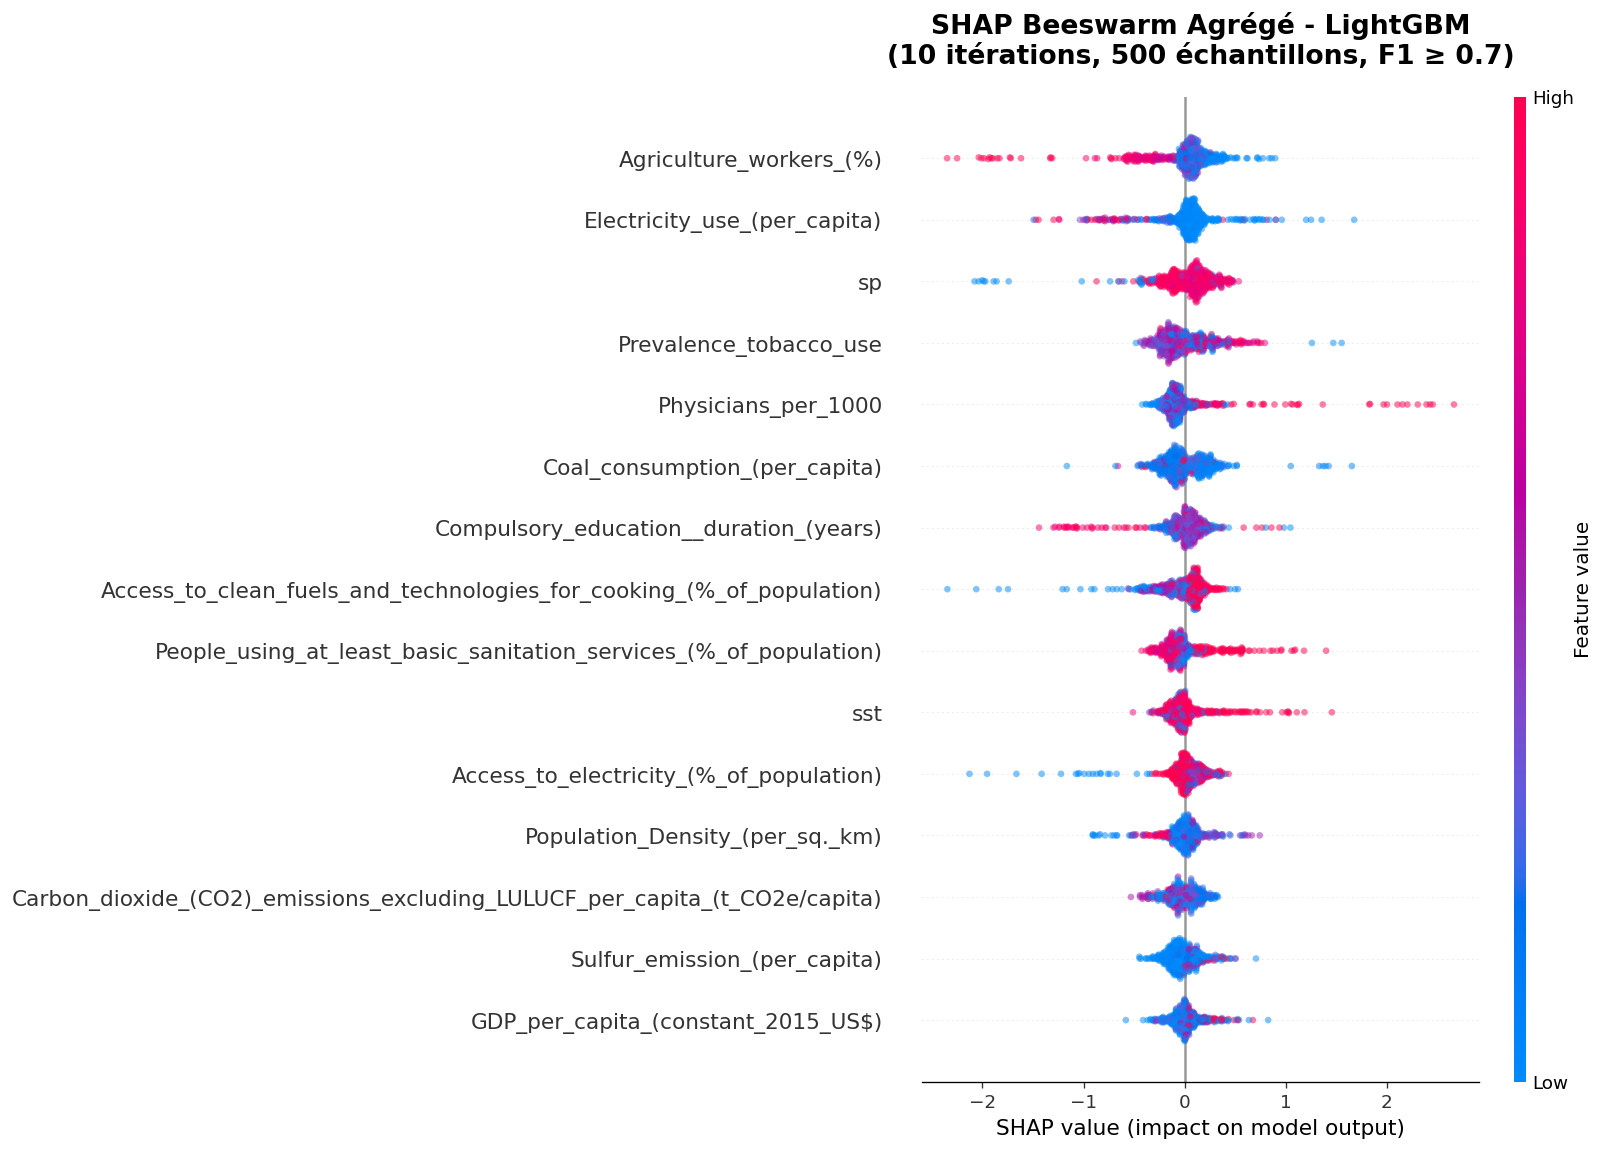

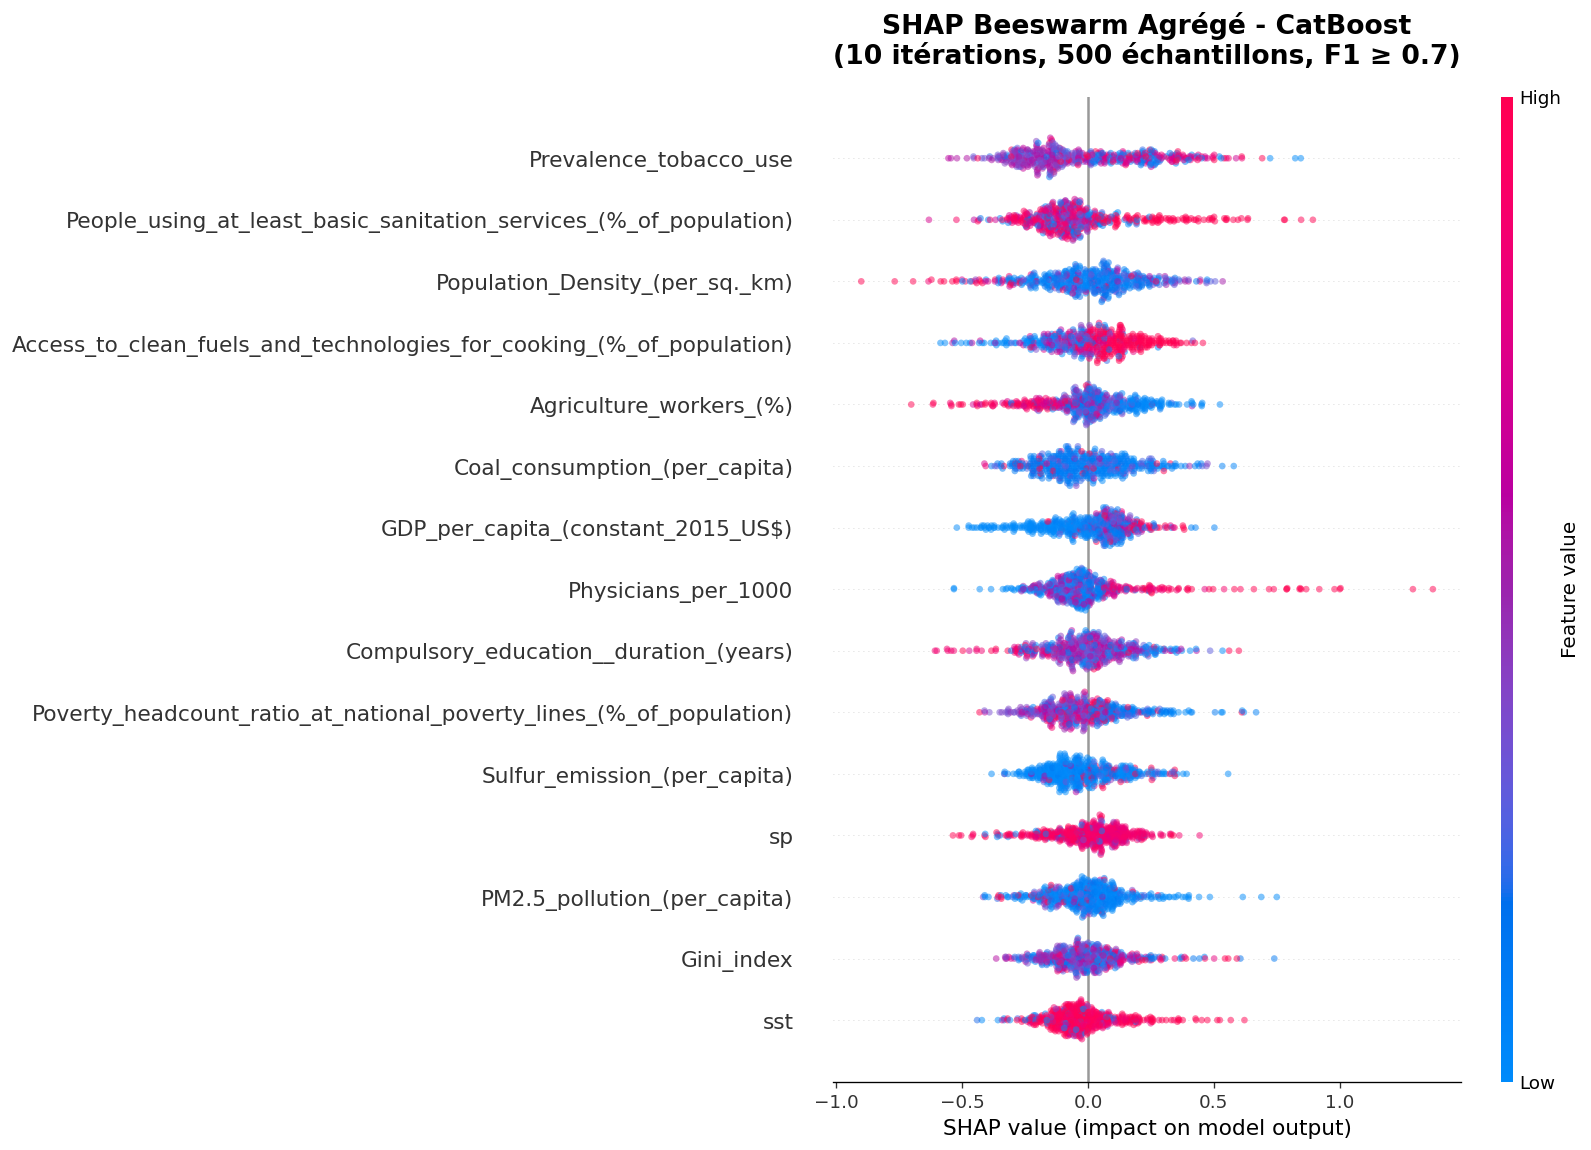

In [35]:
# Beeswarm plots SHAP pour chaque modèle
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11

for model_name, data in aggregated_shap.items():
    fig = plt.figure(figsize=(14, 10), dpi=120)
    
    shap.summary_plot(
        data['shap_values'],
        data['X_data'],
        feature_names=feature_names,
        show=False,
        max_display=15,
        plot_type="dot",
        alpha=0.5,
        plot_size=(14, 10),
        color_bar=True
    )
    
    plt.title(f"SHAP Beeswarm Agrégé - {model_name}\n"
              f"({data['n_iterations']} itérations, {data['total_samples']} échantillons, F1 ≥ {F1_THRESHOLD})", 
              fontsize=16, fontweight='bold', pad=20)
    plt.subplots_adjust(left=0.35, right=0.95, top=0.88, bottom=0.10)
    plt.tight_layout(pad=2.0)
    
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"{output_dir}/shap_beeswarm_{safe_name}.png", dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)

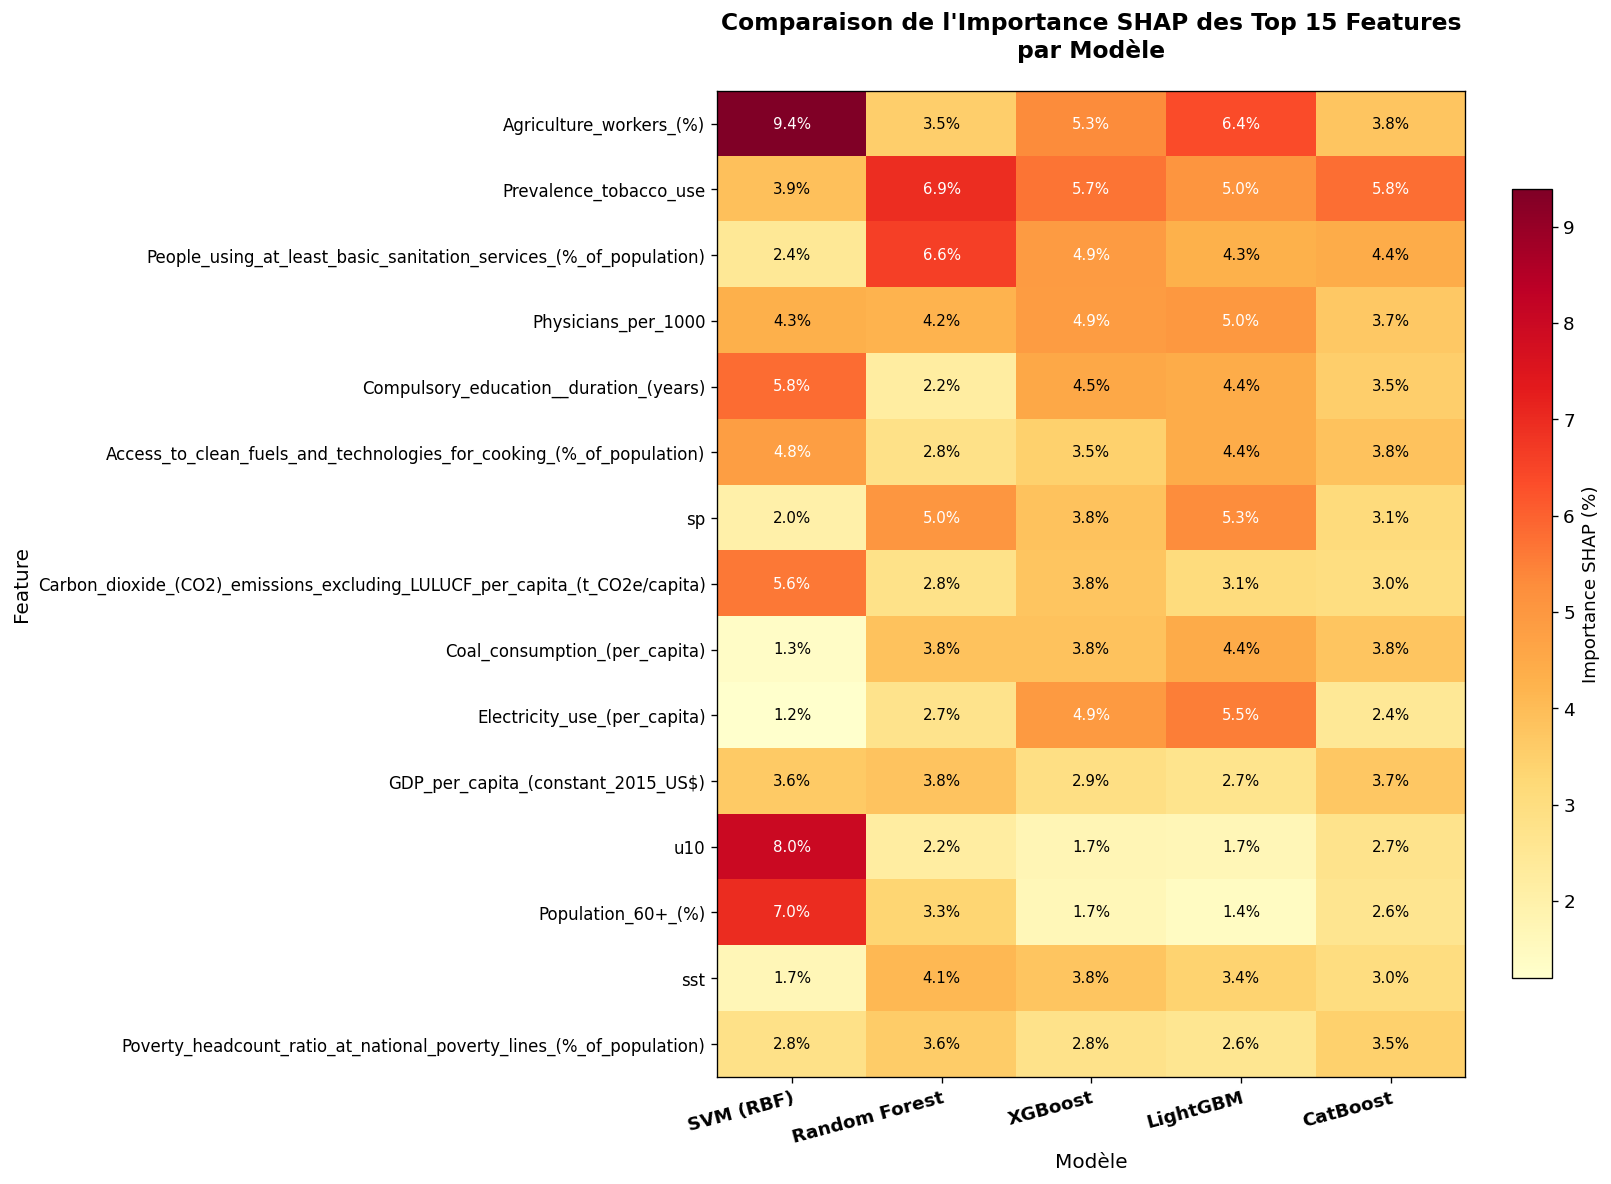

In [36]:
# Comparaison des importances SHAP entre modèles
shap_importance_comparison = {}

for model_name, data in aggregated_shap.items():
    shap_values = data['shap_values']
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance_comparison[model_name] = (mean_abs_shap / mean_abs_shap.sum()) * 100

if shap_importance_comparison:
    df_shap_importance = pd.DataFrame(shap_importance_comparison, index=feature_names)
    df_shap_importance['Moyenne'] = df_shap_importance.mean(axis=1)
    df_shap_importance = df_shap_importance.sort_values('Moyenne', ascending=False)
    
    # Heatmap des Top 15
    fig, ax = plt.subplots(figsize=(14, 10))
    top15_shap = df_shap_importance.head(15).drop(columns=['Moyenne'])
    
    im = ax.imshow(top15_shap.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(np.arange(len(top15_shap.columns)))
    ax.set_yticks(np.arange(len(top15_shap.index)))
    ax.set_xticklabels(top15_shap.columns, fontsize=11, fontweight='bold')
    ax.set_yticklabels(top15_shap.index, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right", rotation_mode="anchor")
    
    for i in range(len(top15_shap.index)):
        for j in range(len(top15_shap.columns)):
            color = "white" if top15_shap.values[i, j] > top15_shap.values.max() * 0.5 else "black"
            ax.text(j, i, f"{top15_shap.values[i, j]:.1f}%", ha="center", va="center", color=color, fontsize=9)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Importance SHAP (%)', fontsize=11)
    ax.set_title("Comparaison de l'Importance SHAP des Top 15 Features\npar Modèle", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Modèle", fontsize=12)
    ax.set_ylabel("Feature", fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_importance_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()

In [37]:
# Analyse de cohérence : Top 5 features par modèle
from collections import Counter

top_n = 5
all_top_features = []

for model_name, importance in shap_importance_comparison.items():
    top_idx = np.argsort(importance)[-top_n:][::-1]
    top_features = [feature_names[i] for i in top_idx]
    all_top_features.extend(top_features)
    print(f"\nTop {top_n} - {model_name}:")
    for rank, idx in enumerate(top_idx, 1):
        print(f"  {rank}. {feature_names[idx]} ({importance[idx]:.2f}%)")

# Features en consensus
feature_frequency = Counter(all_top_features)
print(f"\n{'='*50}")
print("Features les plus fréquentes dans les Top 5 :")
for feat, count in feature_frequency.most_common(10):
    pct = (count / len(shap_importance_comparison)) * 100
    print(f"  {feat}: {count}/{len(shap_importance_comparison)} modèles ({pct:.0f}%)")


Top 5 - SVM (RBF):
  1. Agriculture_workers_(%) (9.39%)
  2. u10 (8.01%)
  3. Population_60+_(%) (6.99%)
  4. Compulsory_education__duration_(years) (5.81%)
  5. Carbon_dioxide_(CO2)_emissions_excluding_LULUCF_per_capita_(t_CO2e/capita) (5.63%)

Top 5 - Random Forest:
  1. Prevalence_tobacco_use (6.93%)
  2. People_using_at_least_basic_sanitation_services_(%_of_population) (6.60%)
  3. sp (5.04%)
  4. Physicians_per_1000 (4.23%)
  5. sst (4.08%)

Top 5 - XGBoost:
  1. Prevalence_tobacco_use (5.69%)
  2. Agriculture_workers_(%) (5.31%)
  3. Electricity_use_(per_capita) (4.93%)
  4. People_using_at_least_basic_sanitation_services_(%_of_population) (4.88%)
  5. Physicians_per_1000 (4.86%)

Top 5 - LightGBM:
  1. Agriculture_workers_(%) (6.36%)
  2. Electricity_use_(per_capita) (5.53%)
  3. sp (5.27%)
  4. Prevalence_tobacco_use (5.05%)
  5. Physicians_per_1000 (5.00%)

Top 5 - CatBoost:
  1. Prevalence_tobacco_use (5.78%)
  2. People_using_at_least_basic_sanitation_services_(%_of_populat

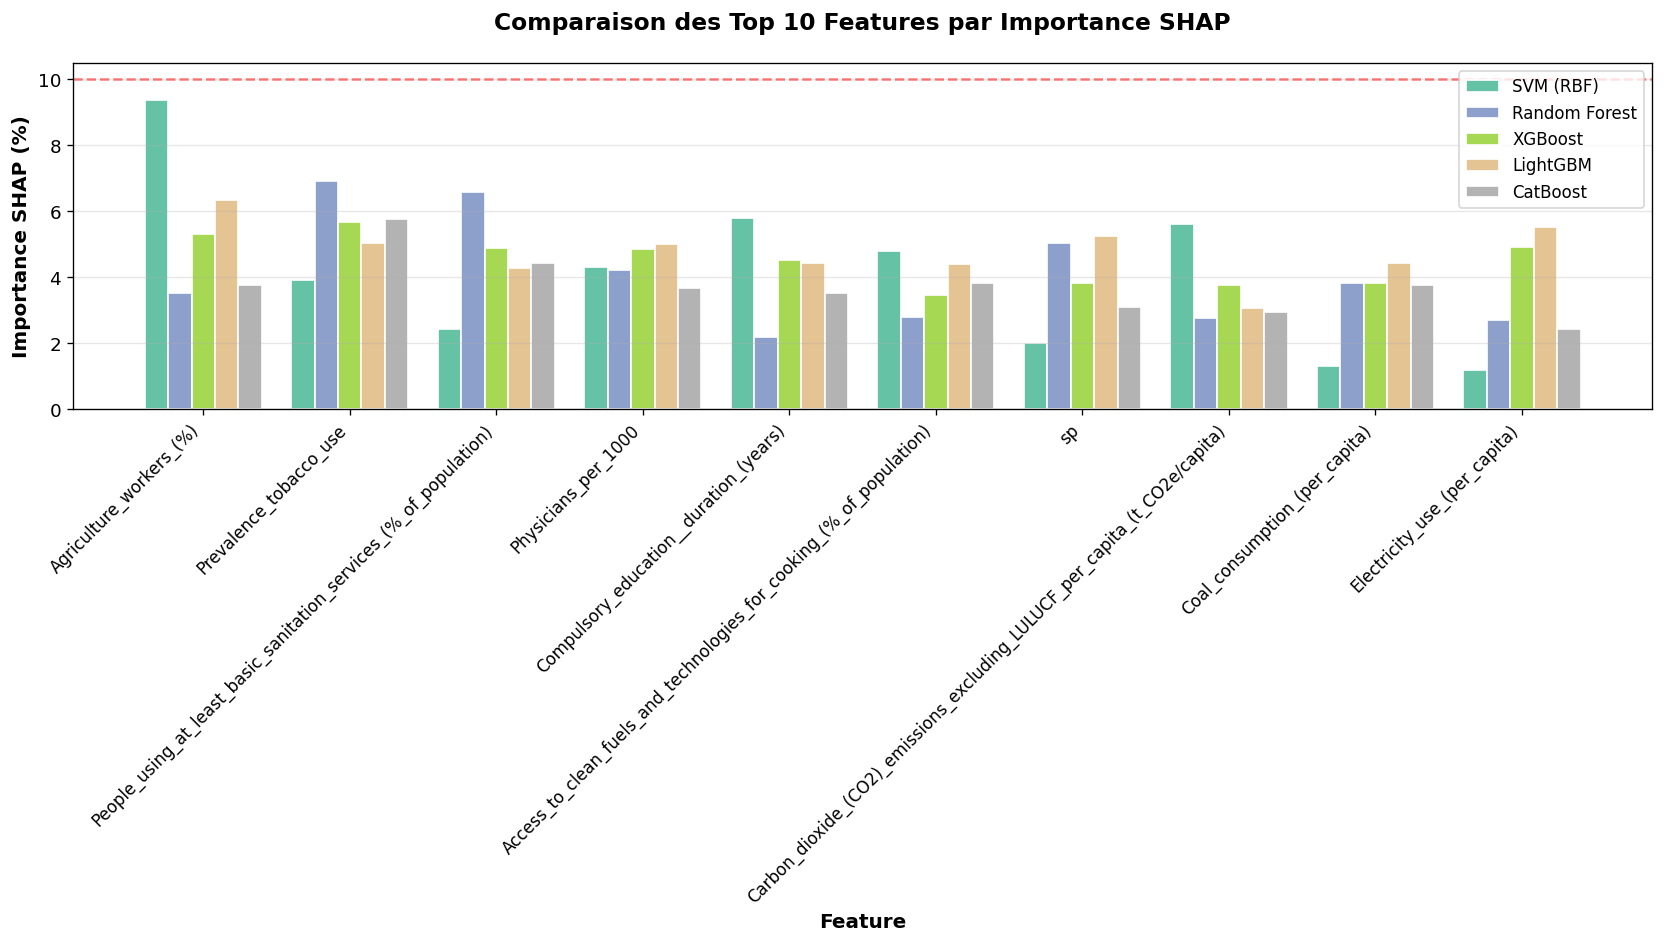


Analyse terminée. Graphiques sauvegardés dans 'outputs_shap/'.


In [38]:
# Bar plot comparatif des Top 10 features
if shap_importance_comparison:
    top10_features = df_shap_importance.head(10).index.tolist()
    
    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(top10_features))
    width = 0.8 / len(shap_importance_comparison)
    colors_shap = plt.cm.Set2(np.linspace(0, 1, len(shap_importance_comparison)))
    
    for i, (model_name, importance) in enumerate(shap_importance_comparison.items()):
        values = [importance[feature_names.index(f)] for f in top10_features]
        offset = (i - len(shap_importance_comparison)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=model_name, color=colors_shap[i], edgecolor='white')
    
    ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
    ax.set_ylabel('Importance SHAP (%)', fontsize=12, fontweight='bold')
    ax.set_title('Comparaison des Top 10 Features par Importance SHAP', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(top10_features, rotation=45, ha='right', fontsize=10)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Seuil 10%')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap_top10_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nAnalyse terminée. Graphiques sauvegardés dans '{output_dir}/'.")